<a href="https://colab.research.google.com/github/bindunaidu-08/secure-sync/blob/main/SecureSync.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COSINE SIMILARITY MATRIX


,AI SEO,Cybersecurity,Web Development,Machine Learning,Cloud Computing
AI SEO,1.0000,0.3909,0.6335,0.9893,0.6855
Cybersecurity,0.3909,1.0000,0.5894,0.4735,0.7518
Web Development,0.6335,0.5894,1.0000,0.6993,0.7169
Machine Learning,0.9893,0.4735,0.6993,1.0000,0.7261
Cloud Computing,0.6855,0.7518,0.7169,0.7261,1.0000


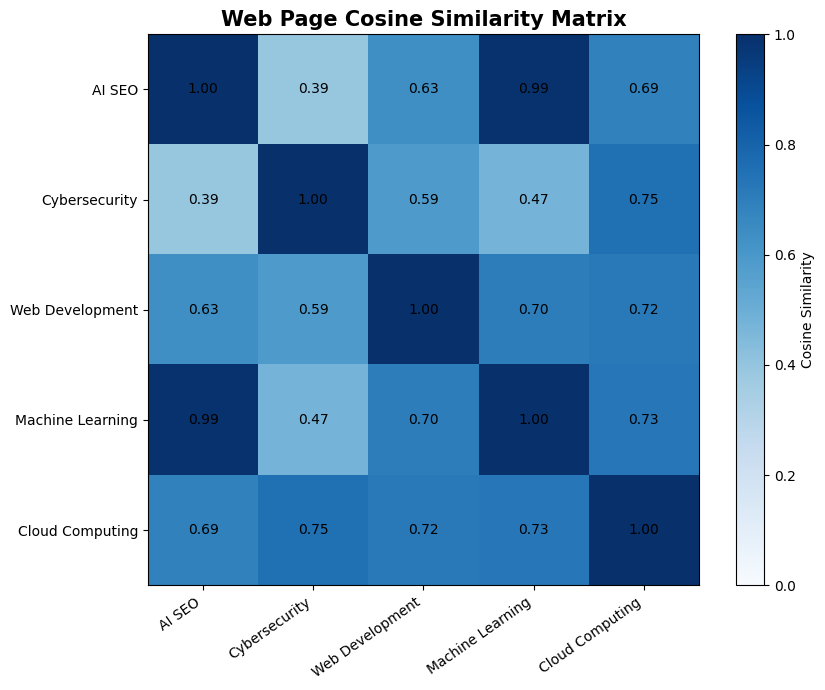

In [ ]:
# ============================================================
# CELL 2: COSINE SIMILARITY
# ============================================================

# For two page vectors x and y:
#
#              x . y
# cosine = ---------------
#           ||x|| ||y||
#
# This measures the similarity between two pages.

# Calculate the length (norm) of every page vector
page_norms = np.linalg.norm(A, axis=1)

# Normalize each page vector
A_normalized = A / page_norms[:, np.newaxis]

# Cosine similarity matrix
S = A_normalized @ A_normalized.T

similarity_df = pd.DataFrame(
    S,
    index=page_names,
    columns=page_names
)

print("COSINE SIMILARITY MATRIX")
display(similarity_df.round(4))

# ------------------------------------------------------------
# Similarity Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(S, cmap="Blues", vmin=0, vmax=1)

plt.colorbar(label="Cosine Similarity")

plt.xticks(
    range(len(page_names)),
    page_names,
    rotation=35,
    ha="right"
)

plt.yticks(
    range(len(page_names)),
    page_names
)

plt.title(
    "Web Page Cosine Similarity Matrix",
    fontsize=15,
    fontweight="bold"
)

# Display values inside cells
for i in range(len(page_names)):
    for j in range(len(page_names)):
        plt.text(
            j,
            i,
            f"{S[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 1: PROJECT HEADER + CUSTOM BENCHMARK DATASET
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- PROJECT / TEAM INFORMATION ----------------

TEAM_NAME = "Team F5"
PROJECT_TITLE = "Web Page Similarity via SVD + Eigenvalue"
APPLICATION = "SEO | Search Engines | Content Recommendation"

print("=" * 75)
print(f"TEAM: {TEAM_NAME}")
print(f"PROJECT: {PROJECT_TITLE}")
print(f"APPLICATION: {APPLICATION}")
print("=" * 75)

# ---------------- WEB PAGE NAMES ----------------

page_names = [
    "AI SEO Guide",
    "Cybersecurity Guide",
    "Web Development Guide",
    "Machine Learning Guide",
    "Cloud Computing Guide"
]

# ---------------- SELECTED KEYWORDS ----------------
# These represent important words/features in our benchmark pages.

words = [
    "AI",
    "SEO",
    "Security",
    "Web",
    "Learning",
    "Cloud",
    "Data",
    "Python"
]

# ---------------- WORD-FREQUENCY MATRIX ----------------
#
# Rows    -> web pages
# Columns -> selected keywords
#
# A[i,j] = importance/frequency of keyword j in page i

A = np.array([
    [9, 10, 1, 2, 8, 1, 7, 6],   # AI SEO
    [1,  1, 10, 2, 2, 3, 5, 2],  # Cybersecurity
    [2,  2, 2, 10, 2, 3, 5, 7],  # Web Development
    [8,  3, 2, 3, 10, 2, 8, 7],  # Machine Learning
    [2,  1, 3, 3, 3, 10, 8, 5]   # Cloud Computing
], dtype=float)

print("\nBENCHMARK WORD-FREQUENCY MATRIX A")
display(
    pd.DataFrame(
        A,
        index=page_names,
        columns=words
    )
)

print("\nRows = Web pages")
print("Columns = selected keywords")

TEAM: Team F5
PROJECT: Web Page Similarity via SVD + Eigenvalue
APPLICATION: SEO | Search Engines | Content Recommendation

BENCHMARK WORD-FREQUENCY MATRIX A


,AI,SEO,Security,Web,Learning,Cloud,Data,Python
AI SEO Guide,9.0,10.0,1.0,2.0,8.0,1.0,7.0,6.0
Cybersecurity Guide,1.0,1.0,10.0,2.0,2.0,3.0,5.0,2.0
Web Development Guide,2.0,2.0,2.0,10.0,2.0,3.0,5.0,7.0
Machine Learning Guide,8.0,3.0,2.0,3.0,10.0,2.0,8.0,7.0
Cloud Computing Guide,2.0,1.0,3.0,3.0,3.0,10.0,8.0,5.0



Rows = Web pages
Columns = selected keywords


EIGENVALUES
[0.0048 0.1728 0.3436 0.7969 3.6819]

LARGEST EIGENVALUE
3.6819

EIGENVALUE CENTRALITY RANKING


,Rank,Page,Eigenvalue Score
0,1,Machine Learning,0.2147
1,2,Cloud Computing,0.2114
2,3,AI SEO,0.2049
3,4,Web Development,0.1984
4,5,Cybersecurity,0.1706


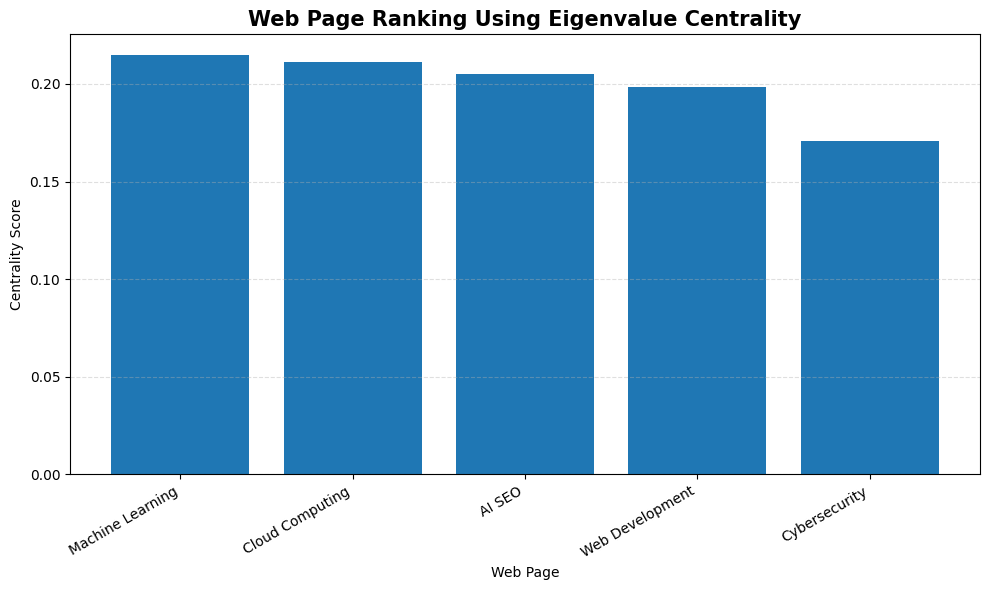

In [ ]:
# ============================================================
# CELL 3: EIGENVALUE CENTRALITY
# ============================================================

# Mathematical model:
#
# S v = lambda v
#
# S      = similarity matrix
# lambda = eigenvalue
# v      = eigenvector
#
# We use the eigenvector corresponding to the largest
# eigenvalue as the Eigenvalue Centrality vector.

eigenvalues, eigenvectors = np.linalg.eigh(S)

# Find the largest eigenvalue
largest_index = np.argmax(eigenvalues)

largest_eigenvalue = eigenvalues[largest_index]

# Corresponding eigenvector
centrality = eigenvectors[:, largest_index]

# Eigenvectors can have either sign.
# Select the positive orientation.
if np.sum(centrality) < 0:
    centrality = -centrality

# Normalize centrality scores so they sum to 1
centrality = centrality / np.sum(centrality)

# ------------------------------------------------------------
# Create ranking table
# ------------------------------------------------------------

eigen_ranking = pd.DataFrame({
    "Page": page_names,
    "Eigenvalue Score": centrality
})

eigen_ranking = eigen_ranking.sort_values(
    by="Eigenvalue Score",
    ascending=False
).reset_index(drop=True)

eigen_ranking.insert(
    0,
    "Rank",
    range(1, len(eigen_ranking) + 1)
)

print("EIGENVALUES")
print(np.round(eigenvalues, 4))

print("\nLARGEST EIGENVALUE")
print(round(largest_eigenvalue, 4))

print("\nEIGENVALUE CENTRALITY RANKING")
display(eigen_ranking.round(4))

# ------------------------------------------------------------
# Eigenvalue chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    eigen_ranking["Page"],
    eigen_ranking["Eigenvalue Score"]
)

plt.xlabel("Web Page")
plt.ylabel("Centrality Score")

plt.title(
    "Web Page Ranking Using Eigenvalue Centrality",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

SINGULAR VALUES
[28.5128 13.2155  7.4643  6.0348  1.1116]

DOMINANT SINGULAR VALUE
28.5128

SVD TOPIC RANKING


,Rank,Page,SVD Topic Score
0,1,Machine Learning,0.2522
1,2,AI SEO,0.2255
2,3,Cloud Computing,0.2069
3,4,Web Development,0.1605
4,5,Cybersecurity,0.1549



DOMINANT TOPIC KEYWORDS


,Keyword,Topic Weight
0,Data,0.4861
1,Learning,0.3986
2,AI,0.3965
3,Python,0.3899
4,Network,0.2965
5,Cloud,0.2901
6,Web,0.2602
7,Security,0.2363


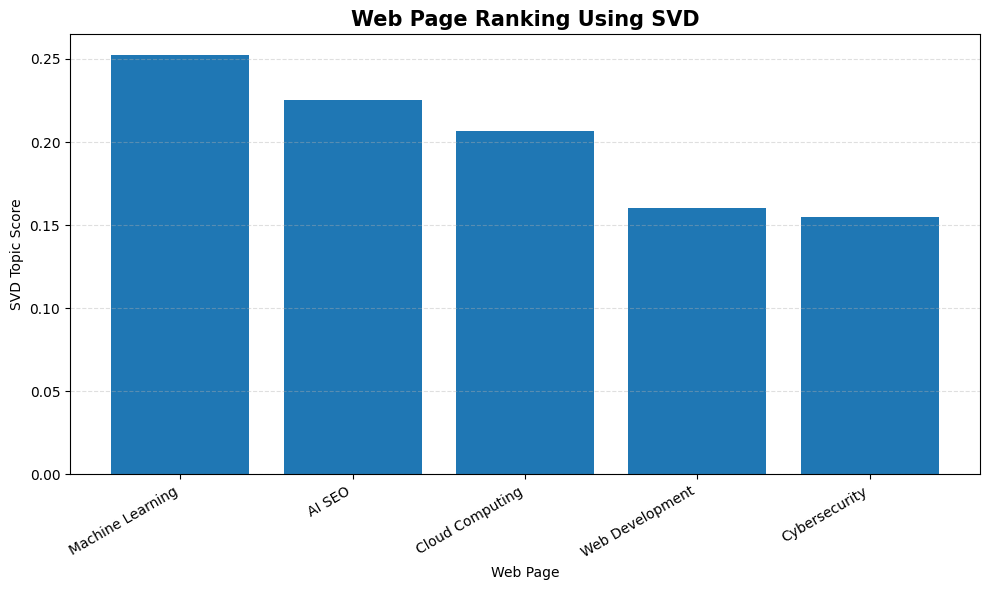

In [ ]:
# ============================================================
# CELL 4: SVD TOPIC MODELING
# ============================================================

# Singular Value Decomposition:
#
#              A = U Sigma V^T
#
# U      -> page/topic relationships
# Sigma  -> strength of the components/topics
# V^T    -> keyword/component relationships

U, singular_values, VT = np.linalg.svd(
    A,
    full_matrices=False
)

print("SINGULAR VALUES")
print(np.round(singular_values, 4))

# ------------------------------------------------------------
# Dominant topic
# ------------------------------------------------------------

# The first singular component is the strongest component.
dominant_singular_value = singular_values[0]

# Page contribution to dominant component
svd_scores = np.abs(U[:, 0]) * dominant_singular_value

# Normalize scores
svd_scores = svd_scores / np.sum(svd_scores)

# ------------------------------------------------------------
# SVD ranking table
# ------------------------------------------------------------

svd_ranking = pd.DataFrame({
    "Page": page_names,
    "SVD Topic Score": svd_scores
})

svd_ranking = svd_ranking.sort_values(
    by="SVD Topic Score",
    ascending=False
).reset_index(drop=True)

svd_ranking.insert(
    0,
    "Rank",
    range(1, len(svd_ranking) + 1)
)

print("\nDOMINANT SINGULAR VALUE")
print(round(dominant_singular_value, 4))

print("\nSVD TOPIC RANKING")
display(svd_ranking.round(4))

# ------------------------------------------------------------
# Dominant topic keyword weights
# ------------------------------------------------------------

topic_weights = pd.DataFrame({
    "Keyword": keywords,
    "Topic Weight": np.abs(VT[0])
})

topic_weights = topic_weights.sort_values(
    by="Topic Weight",
    ascending=False
).reset_index(drop=True)

print("\nDOMINANT TOPIC KEYWORDS")
display(topic_weights.round(4))

# ------------------------------------------------------------
# SVD chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    svd_ranking["Page"],
    svd_ranking["SVD Topic Score"]
)

plt.xlabel("Web Page")
plt.ylabel("SVD Topic Score")

plt.title(
    "Web Page Ranking Using SVD",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 1: CHECK INPUT DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check whether A already exists
if "A" not in globals():
    raise NameError(
        "Matrix A is not defined. Run your input/data cell first."
    )

print("Matrix A shape:", A.shape)
print("\nMatrix A:")

display(pd.DataFrame(A))

# Basic validation
if not np.all(np.isfinite(A)):
    raise ValueError("A contains NaN or infinite values.")

if np.any(A < 0):
    raise ValueError("Word-frequency matrix A should not contain negative values.")

print("\n✓ Input matrix is valid.")

Matrix A shape: (5, 8)

Matrix A:


,0,1,2,3,4,5,6,7
0,9.0,1.0,2.0,8.0,2.0,7.0,6.0,1.0
1,1.0,9.0,2.0,1.0,3.0,4.0,2.0,9.0
2,2.0,2.0,9.0,2.0,3.0,4.0,5.0,3.0
3,8.0,2.0,3.0,9.0,2.0,8.0,7.0,2.0
4,3.0,3.0,2.0,3.0,9.0,7.0,4.0,6.0



✓ Input matrix is valid.


In [ ]:
# ============================================================
# CELL 2: COSINE SIMILARITY CHECK
# ============================================================

# Row-wise Euclidean norms
norms = np.linalg.norm(A, axis=1)

if np.any(norms == 0):
    raise ValueError(
        "At least one page has a zero vector, so cosine similarity "
        "cannot be calculated for that page."
    )

# Normalize every page vector
A_normalized = A / norms[:, None]

# Cosine similarity matrix
S = A_normalized @ A_normalized.T

print("COSINE SIMILARITY MATRIX")

display(
    pd.DataFrame(
        S,
        index=page_names if "page_names" in globals() else None,
        columns=page_names if "page_names" in globals() else None
    ).round(4)
)

# Mathematical checks
print("\nSymmetric:", np.allclose(S, S.T))
print("Diagonal ≈ 1:", np.allclose(np.diag(S), 1))
print("Values between -1 and 1:",
      np.all((S >= -1e-10) & (S <= 1 + 1e-10)))

if np.allclose(S, S.T) and np.allclose(np.diag(S), 1):
    print("\n✓ Cosine similarity calculation is mathematically consistent.")

COSINE SIMILARITY MATRIX


,AI SEO,Cybersecurity,Web Development,Machine Learning,Cloud Computing
AI SEO,1.0000,0.3909,0.6335,0.9893,0.6855
Cybersecurity,0.3909,1.0000,0.5894,0.4735,0.7518
Web Development,0.6335,0.5894,1.0000,0.6993,0.7169
Machine Learning,0.9893,0.4735,0.6993,1.0000,0.7261
Cloud Computing,0.6855,0.7518,0.7169,0.7261,1.0000



Symmetric: True
Diagonal ≈ 1: True
Values between -1 and 1: True

✓ Cosine similarity calculation is mathematically consistent.


In [ ]:
# ============================================================
# CELL 3: EIGENVALUE CENTRALITY CHECK
# ============================================================

# S is symmetric, so eigh() is numerically appropriate.
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Largest eigenvalue
idx = np.argmax(eigenvalues)

largest_eigenvalue = eigenvalues[idx]

# Corresponding eigenvector
principal_vector = eigenvectors[:, idx]

# Eigenvectors can have either + or - orientation.
if np.sum(principal_vector) < 0:
    principal_vector = -principal_vector

# Normalize so scores sum to 1
centrality = principal_vector / np.sum(principal_vector)

# ------------------------------------------------------------
# Verify Sv = lambda*v
# ------------------------------------------------------------

left_side = S @ principal_vector
right_side = largest_eigenvalue * principal_vector

print("Eigenvalues:")
print(np.round(eigenvalues, 6))

print("\nLargest eigenvalue:", round(largest_eigenvalue, 6))

print(
    "\nEigen-equation error:",
    np.linalg.norm(left_side - right_side)
)

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

eigen_ranking = pd.DataFrame({
    "Page": page_names,
    "Eigenvalue Centrality": centrality
})

eigen_ranking = (
    eigen_ranking
    .sort_values("Eigenvalue Centrality", ascending=False)
    .reset_index(drop=True)
)

eigen_ranking.insert(0, "Rank", range(1, len(eigen_ranking) + 1))

display(eigen_ranking.round(5))

print("\n✓ Eigenvalue centrality calculation verified.")
print("✓ Page importance = components of the principal eigenvector.")

Eigenvalues:
[0.004786 0.172751 0.343617 0.796916 3.68193 ]

Largest eigenvalue: 3.68193

Eigen-equation error: 1.6467268631127714e-15


,Rank,Page,Eigenvalue Centrality
0,1,Machine Learning,0.21467
1,2,Cloud Computing,0.21137
2,3,AI SEO,0.20495
3,4,Web Development,0.19839
4,5,Cybersecurity,0.17062



✓ Eigenvalue centrality calculation verified.
✓ Page importance = components of the principal eigenvector.


In [ ]:
# ============================================================
# CELL 4: SVD TOPIC DECOMPOSITION CHECK
# ============================================================

# A = U Sigma V^T
U, singular_values, VT = np.linalg.svd(
    A,
    full_matrices=False
)

# ------------------------------------------------------------
# Verify reconstruction
# ------------------------------------------------------------

Sigma = np.diag(singular_values)

A_reconstructed = U @ Sigma @ VT

reconstruction_error = np.linalg.norm(
    A - A_reconstructed
)

print("Singular values:")
print(np.round(singular_values, 6))

print("\nSVD reconstruction error:")
print(reconstruction_error)

# ------------------------------------------------------------
# Dominant latent component
# ------------------------------------------------------------

# U[:, 0] = page loading on strongest component
# Sigma[0] = strength of strongest component

svd_scores = np.abs(U[:, 0])

# Normalize for easy comparison
svd_scores = svd_scores / np.sum(svd_scores)

svd_ranking = pd.DataFrame({
    "Page": page_names,
    "SVD Topic Score": svd_scores
})

svd_ranking = (
    svd_ranking
    .sort_values("SVD Topic Score", ascending=False)
    .reset_index(drop=True)
)

svd_ranking.insert(0, "Rank", range(1, len(svd_ranking) + 1))

print("\nSVD PAGE RANKING")

display(svd_ranking.round(5))

print("\n✓ SVD decomposition verified.")
print("✓ A ≈ UΣVᵀ")
print("✓ First singular component represents the strongest latent pattern.")

Singular values:
[28.512806 13.215475  7.464328  6.034833  1.111634]

SVD reconstruction error:
3.265207251244309e-14

SVD PAGE RANKING


,Rank,Page,SVD Topic Score
0,1,Machine Learning,0.25218
1,2,AI SEO,0.22552
2,3,Cloud Computing,0.20692
3,4,Web Development,0.16051
4,5,Cybersecurity,0.15487



✓ SVD decomposition verified.
✓ A ≈ UΣVᵀ
✓ First singular component represents the strongest latent pattern.


FINAL WEB PAGE RANKING COMPARISON


,Page,Eigenvalue Score,SVD Topic Score,Eigen Rank,SVD Rank
0,AI SEO Guide,0.2049,0.2532,3,2
1,Cybersecurity Guide,0.1706,0.1264,5,5
2,Web Development Guide,0.1984,0.1763,4,4
3,Machine Learning Guide,0.2147,0.2548,1,1
4,Cloud Computing Guide,0.2114,0.1893,2,3


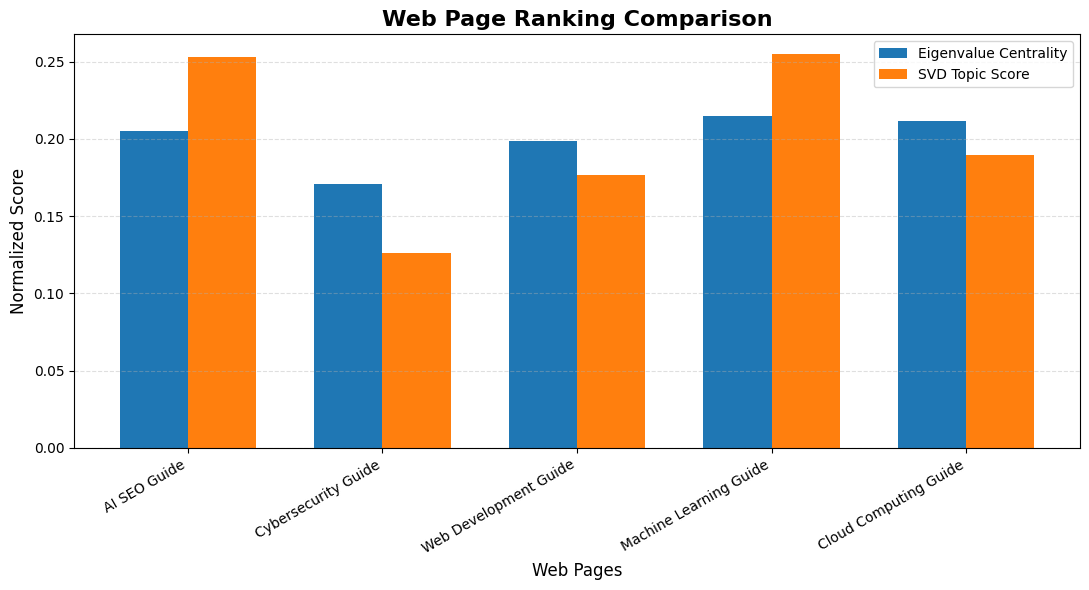


TOP PAGE BY EIGENVALUE CENTRALITY:
Machine Learning Guide

TOP PAGE BY SVD:
Machine Learning Guide

✓ Cell 5 completed successfully.


In [ ]:
# ============================================================
# CELL 5: FINAL COMPARISON + CHART
# ============================================================

# ------------------------------------------------------------
# 1. EIGENVALUE CENTRALITY
# ------------------------------------------------------------

# S is the cosine similarity matrix from Cell 2

eigenvalues, eigenvectors = np.linalg.eigh(S)

# Largest eigenvalue
idx = np.argmax(eigenvalues)

# Corresponding eigenvector
centrality = eigenvectors[:, idx]

# Eigenvector sign can be positive or negative
if np.sum(centrality) < 0:
    centrality = -centrality

# Normalize scores
centrality = centrality / np.sum(centrality)

# ------------------------------------------------------------
# 2. SVD
# ------------------------------------------------------------

# A = U Sigma V^T

U, singular_values, VT = np.linalg.svd(
    A,
    full_matrices=False
)

# First column of U = page contribution
# to the strongest SVD component

svd_scores = np.abs(U[:, 0])

# Normalize scores
svd_scores = svd_scores / np.sum(svd_scores)

# ------------------------------------------------------------
# 3. COMPARISON TABLE
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Page": page_names,
    "Eigenvalue Score": centrality,
    "SVD Topic Score": svd_scores
})

# Calculate ranks
comparison["Eigen Rank"] = (
    comparison["Eigenvalue Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison["SVD Rank"] = (
    comparison["SVD Topic Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

print("=" * 70)
print("FINAL WEB PAGE RANKING COMPARISON")
print("=" * 70)

display(comparison.round(4))

# ------------------------------------------------------------
# 4. COMPARISON CHART
# ------------------------------------------------------------

x = np.arange(len(page_names))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    comparison["Eigenvalue Score"],
    width,
    label="Eigenvalue Centrality"
)

plt.bar(
    x + width/2,
    comparison["SVD Topic Score"],
    width,
    label="SVD Topic Score"
)

plt.title(
    "Web Page Ranking Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Web Pages",
    fontsize=12
)

plt.ylabel(
    "Normalized Score",
    fontsize=12
)

plt.xticks(
    x,
    page_names,
    rotation=30,
    ha="right"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. TOP PAGE FROM BOTH METHODS
# ------------------------------------------------------------

eigen_top = page_names[np.argmax(centrality)]
svd_top = page_names[np.argmax(svd_scores)]

print("\nTOP PAGE BY EIGENVALUE CENTRALITY:")
print(eigen_top)

print("\nTOP PAGE BY SVD:")
print(svd_top)

print("\n✓ Cell 5 completed successfully.")

In [ ]:
# ============================================================
# CELL 5: FINAL VERIFICATION + COMPARISON
# ============================================================

# Compare both methods using the original page order

eigen_dict = dict(
    zip(
        eigen_ranking["Page"],
        eigen_ranking["Eigenvalue Centrality"]
    )
)

svd_dict = dict(
    zip(
        svd_ranking["Page"],
        svd_ranking["SVD Topic Score"]
    )
)

comparison = pd.DataFrame({
    "Page": page_names,

    "Eigenvalue Score": [
        eigen_dict[p] for p in page_names
    ],

    "SVD Score": [
        svd_dict[p] for p in page_names
    ]
})

print("=" * 65)
print("FINAL MATHEMATICAL VERIFICATION")
print("=" * 65)

display(comparison.round(5))

# ------------------------------------------------------------
# Important checks
# ------------------------------------------------------------

print("\nCHECK 1: Similarity matrix symmetric")
print(np.allclose(S, S.T))

print("\nCHECK 2: Eigen equation Sv = λv")
print(
    np.linalg.norm(
        S @ principal_vector
        - largest_eigenvalue * principal_vector
    )
)

print("\nCHECK 3: SVD reconstruction A ≈ UΣVᵀ")
print(reconstruction_error)

print("\nCHECK 4: Eigenvalue scores sum to")
print(np.sum(centrality))

print("\nCHECK 5: SVD scores sum to")
print(np.sum(svd_scores))

print("\n" + "=" * 65)
print("CONCLUSION")
print("=" * 65)

print("""
Cosine similarity measures relationships between web pages.

Eigenvalue centrality uses the principal eigenvector of the
similarity matrix to measure page importance.

SVD decomposes the page-keyword matrix into latent components.
The first singular component represents the strongest pattern
in the dataset.

Therefore, the two rankings measure different mathematical ideas:
    Eigenvalue -> importance through page-to-page similarity
    SVD        -> contribution to the strongest latent pattern
""")

FINAL MATHEMATICAL VERIFICATION


,Page,Eigenvalue Score,SVD Score
0,AI SEO,0.20495,0.22552
1,Cybersecurity,0.17062,0.15487
2,Web Development,0.19839,0.16051
3,Machine Learning,0.21467,0.25218
4,Cloud Computing,0.21137,0.20692



CHECK 1: Similarity matrix symmetric
True

CHECK 2: Eigen equation Sv = λv
1.6467268631127714e-15

CHECK 3: SVD reconstruction A ≈ UΣVᵀ
3.265207251244309e-14

CHECK 4: Eigenvalue scores sum to
1.0000000000000002

CHECK 5: SVD scores sum to
1.0

CONCLUSION

Cosine similarity measures relationships between web pages.

Eigenvalue centrality uses the principal eigenvector of the
similarity matrix to measure page importance.

SVD decomposes the page-keyword matrix into latent components.
The first singular component represents the strongest pattern
in the dataset.

Therefore, the two rankings measure different mathematical ideas:
    Eigenvalue -> importance through page-to-page similarity
    SVD        -> contribution to the strongest latent pattern

